# Multimodal THOR Inference – S1 + S2 + S3

This notebook loads exported GeoTIFFs and runs two THOR
forward passes to show different output modes:

1. **`merge_method="mean"`** – all modality token grids are interpolated to
   the finest resolution and averaged, producing one `(B, D, H, W)` feature
   map per encoder block.
2. **`merge_method="group"`** – each modality keeps its own token grid at
   native resolution, returning a `dict[str, Tensor]` per block. This is
   useful for downstream heads that treat modalities independently.

### Modalities

| Input key | Sensor | Channels | GSD |
|---|---|---|---|
| `S1GRD` | Sentinel-1 GRD IW | 2 (VV, VH) | 10/20/60 m |
| `S2L2A` | Sentinel-2 L2A | 12 (B01–B12) | 10 m |
| `S3OLCI` | Sentinel-3 OLCI reflectance | 21 (Oa01–Oa21) | 240 m |
| `S3SLSTR_REFL` | Sentinel-3 SLSTR reflectance | 6 (S1–S6 nadir) | 480 m |
| `S3SLSTR_BT` | Sentinel-3 SLSTR brightness temperature | 3 (S7–S9) | 960 m |

`THOREncoderWrapper._preprocess_input` resizes every band to
`ground_cover / GSD` pixels automatically, so input tensors can arrive at any
spatial size.


THOR has experimental support for a flex attention optimized alibi attention implementation, which allows for processing larger inputs. Enable with `USE_FLEX_ATTENTION=1` before importing THOR.

In [1]:
import os

# Enable memory efficient attention in THOR by setting the environment variable before importing THOR.
os.environ["USE_FLEX_ATTENTION"] = "1"

In [2]:
from pathlib import Path

import numpy as np
import rasterio
import torch
import matplotlib.pyplot as plt

from terratorch.registry import TERRATORCH_BACKBONE_REGISTRY as BACKBONE_REGISTRY

from thor_terratorch_ext.datasets.utils import (
    MODALITY_BAND_MAPPING,
    S2L2ABands,
    S3OLCIBands,
    SARThorBands,
    S3SLSTRBands,
    ThorModalities,
)
from thor_terratorch_ext.models.backbones.thor_vit import normalise_for_thor

2026-04-14 15:01:18,262 - INFO - Patching timm Attention and Block to use Alibi...
2026-04-14 15:01:18,263 - INFO - Using flex attention for timm Attention


## Configuration

In [ ]:
DATA_DIR = Path("./out/9_s1_s2_s3_thor_workflow_axis_aligned_square")

TIFF_PATHS = {
    ThorModalities.S1GRD_VV_VH: DATA_DIR / "s1_grd_10m.tif",
    ThorModalities.S2L2A: DATA_DIR / "s2_l2a_10m.tif",
    ThorModalities.S3OLCI: DATA_DIR / "s3_olci_240m.tif",
    ThorModalities.S3SLSTR_REFL: DATA_DIR / "s3_slstr_reflectance_480m.tif",
    ThorModalities.S3SLSTR_BT: DATA_DIR / "s3_slstr_bt_960m.tif",
}

MODEL_NAME = "thor_v1_tiny"  # tiny | small | base | large

# Infer ground_cover from the finest-resolution GeoTIFF: GSD * max(width, height).
with rasterio.open(TIFF_PATHS[ThorModalities.S2L2A]) as src:
    gsd = src.transform.a  # pixel size in metres
    GROUND_COVER = int(gsd * max(src.width, src.height))
    print(
        f"Inferred ground cover from S2 TIFF: {gsd:.0f} m/px × "
        f"{max(src.width, src.height)} px = {GROUND_COVER} m"
    )

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  Ground cover: {GROUND_COVER} m")

Inferred ground cover from S2 TIFF: 10 m/px × 2688 px = 26880 m
Device: cuda  |  Ground cover: 26880 m


## Load GeoTIFFs

In [4]:
def read_tiff(path: Path) -> np.ndarray:
    """Return a float32 (C, H, W) array with NaN preserved."""
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)


arrays: dict[ThorModalities, np.ndarray] = {}
for modality, path in TIFF_PATHS.items():
    arrays[modality] = read_tiff(path)
    print(
        f"{modality.value:20s}  shape={arrays[modality].shape}  "
        f"nan={np.isnan(arrays[modality]).sum()}"
    )

S1GRD_VV_VH           shape=(2, 2688, 2688)  nan=2555478
S2L2A                 shape=(12, 2688, 2688)  nan=0
S3OLCI                shape=(21, 112, 112)  nan=0
S3SLSTR_REFL          shape=(6, 56, 56)  nan=0
S3SLSTR_BT            shape=(3, 28, 28)  nan=0


## Prepare tensors

Each modality array is:
1. normalised using THOR pretraining statistics (`normalise_for_thor`),
   which also replaces NaN with the band mean,
2. any remaining NaN (outside sensor coverage) filled with the per-channel
   median,
3. converted to a `(1, C, H, W)` float32 tensor.

In [5]:
def fill_nan_with_channel_median(arr: np.ndarray) -> np.ndarray:
    """Replace NaN in each channel with that channel's median (fallback 0)."""
    out = arr.copy()
    for c in range(out.shape[0]):
        band = out[c]
        mask = np.isnan(band)
        if mask.any():
            median = np.nanmedian(band)
            band[mask] = median if np.isfinite(median) else 0.0
    return out


inputs: dict[str, torch.Tensor] = {}
for modality, arr in arrays.items():
    band_keys = MODALITY_BAND_MAPPING[modality]
    normed = normalise_for_thor(arr, band_keys)
    normed = fill_nan_with_channel_median(normed)
    t = torch.from_numpy(normed)  # (C, H, W)
    inputs[modality.value] = t.unsqueeze(0).to(DEVICE)  # (1, C, H, W)
    print(f"{modality.value:20s}  tensor shape: {inputs[modality.value].shape}")

S1GRD_VV_VH           tensor shape: torch.Size([1, 2, 2688, 2688])
S2L2A                 tensor shape: torch.Size([1, 12, 2688, 2688])
S3OLCI                tensor shape: torch.Size([1, 21, 112, 112])
S3SLSTR_REFL          tensor shape: torch.Size([1, 6, 56, 56])
S3SLSTR_BT            tensor shape: torch.Size([1, 3, 28, 28])


## Model Bands

We use modalities from all three sensors. Either build the backbone using the old `model_bands` argument, or use `modalities` for ease of use.

In [6]:
S1_BANDS = [SARThorBands.IW_VV, SARThorBands.IW_VH]
S2_BANDS = list(S2L2ABands)  # all 12 L2A reflectance bands
S3_OLCI_BANDS = list(S3OLCIBands)  # all 21 OLCI reflectance bands
S3_SLSTR_BANDS = list(S3SLSTRBands)  # 6 reflectance (S1–S6) + 3 BT (S7–S9)

ALL_BANDS = S1_BANDS + S2_BANDS + S3_OLCI_BANDS + S3_SLSTR_BANDS
print(
    f"S1: {len(S1_BANDS)}, S2: {len(S2_BANDS)}, "
    f"OLCI: {len(S3_OLCI_BANDS)}, SLSTR: {len(S3_SLSTR_BANDS)}"
)
print(f"Total bands: {len(ALL_BANDS)}")

S1: 2, S2: 12, OLCI: 21, SLSTR: 9
Total bands: 44


## Load THOR backbone (`merge_method="mean"`)
All modality token grids are interpolated to the finest spatial resolution and
averaged into one feature map per encoder block.

In [7]:
backbone = BACKBONE_REGISTRY.build(
    MODEL_NAME,
    pretrained=True,
    # model_bands=ALL_BANDS,
    modalities=["S1GRD", "S2L2A", "S3OLCI", "S3SLSTR_REFL", "S3SLSTR_BT"],
    ground_cover=GROUND_COVER,
    patch_sizes={
        "S1GRD": [32],
        "S2L2A": [32],
        "S3OLCI": [16],
        "S3SLSTR_REFL": [8],
        "S3SLSTR_BT": [4],
    },
    select_patch_strategy="min",
    merge_method="mean",
)
backbone = backbone.to(DEVICE).eval()
print(
    f"Input size: {backbone.input_size} px  |  Embedding dim: {backbone.out_channels[0]}"
)

2026-04-14 15:01:21,014 - INFO - Deriving model bands from modalities: ['S1GRD', 'S2L2A', 'S3OLCI', 'S3SLSTR_REFL', 'S3SLSTR_BT']
2026-04-14 15:01:21,015 - INFO - Using pretrained weights for model encoder
2026-04-14 15:01:21,218 - INFO - HTTP Request: HEAD https://huggingface.co/FM4CS/THOR-1.0-tiny/resolve/main/thor_v1_vit_tiny.pt "HTTP/1.1 302 Found"
2026-04-14 15:01:21,220 - INFO - Instantiating model encoder of type thor_vit_tiny_encoder_alibi_patch_size_embed_v1
2026-04-14 15:01:21,221 - INFO -   group0: S2 [Red, Green, Blue, NIR] (GSD=10, patch_size=16)
2026-04-14 15:01:21,222 - INFO -   group1: S2 [RE1, RE2, RE3, RE4, SWIR1, SWIR2] (GSD=20, patch_size=16)
2026-04-14 15:01:21,223 - INFO -   group2: S2 [CoastAerosal, WaterVapor] (GSD=60, patch_size=16)
2026-04-14 15:01:21,223 - INFO -   group3: S1 [IW-VH, IW-VV, EW-VH, EW-VV] (GSD=10, patch_size=16)
2026-04-14 15:01:21,224 - INFO -   group4: S1 [IW-HV, IW-HH, EW-HV, EW-HH] (GSD=10, patch_size=16)
2026-04-14 15:01:21,225 - INFO -  

Input size: 2688 px  |  Embedding dim: 192


## Forward pass (`merge_method="mean"`)

In [8]:
with torch.no_grad():
    features = backbone(inputs)

print(f"Number of output layers: {len(features)}")
for i, f in enumerate(features):
    print(f"  Layer {i:2d}: {tuple(f.shape)}")

2026-04-14 15:01:22,426 - INFO - Compiling flex_attention for fused attention kernels


Number of output layers: 12
  Layer  0: (1, 192, 84, 84)
  Layer  1: (1, 192, 84, 84)
  Layer  2: (1, 192, 84, 84)
  Layer  3: (1, 192, 84, 84)
  Layer  4: (1, 192, 84, 84)
  Layer  5: (1, 192, 84, 84)
  Layer  6: (1, 192, 84, 84)
  Layer  7: (1, 192, 84, 84)
  Layer  8: (1, 192, 84, 84)
  Layer  9: (1, 192, 84, 84)
  Layer 10: (1, 192, 84, 84)
  Layer 11: (1, 192, 84, 84)


## Visualise inputs and last-layer merged feature map

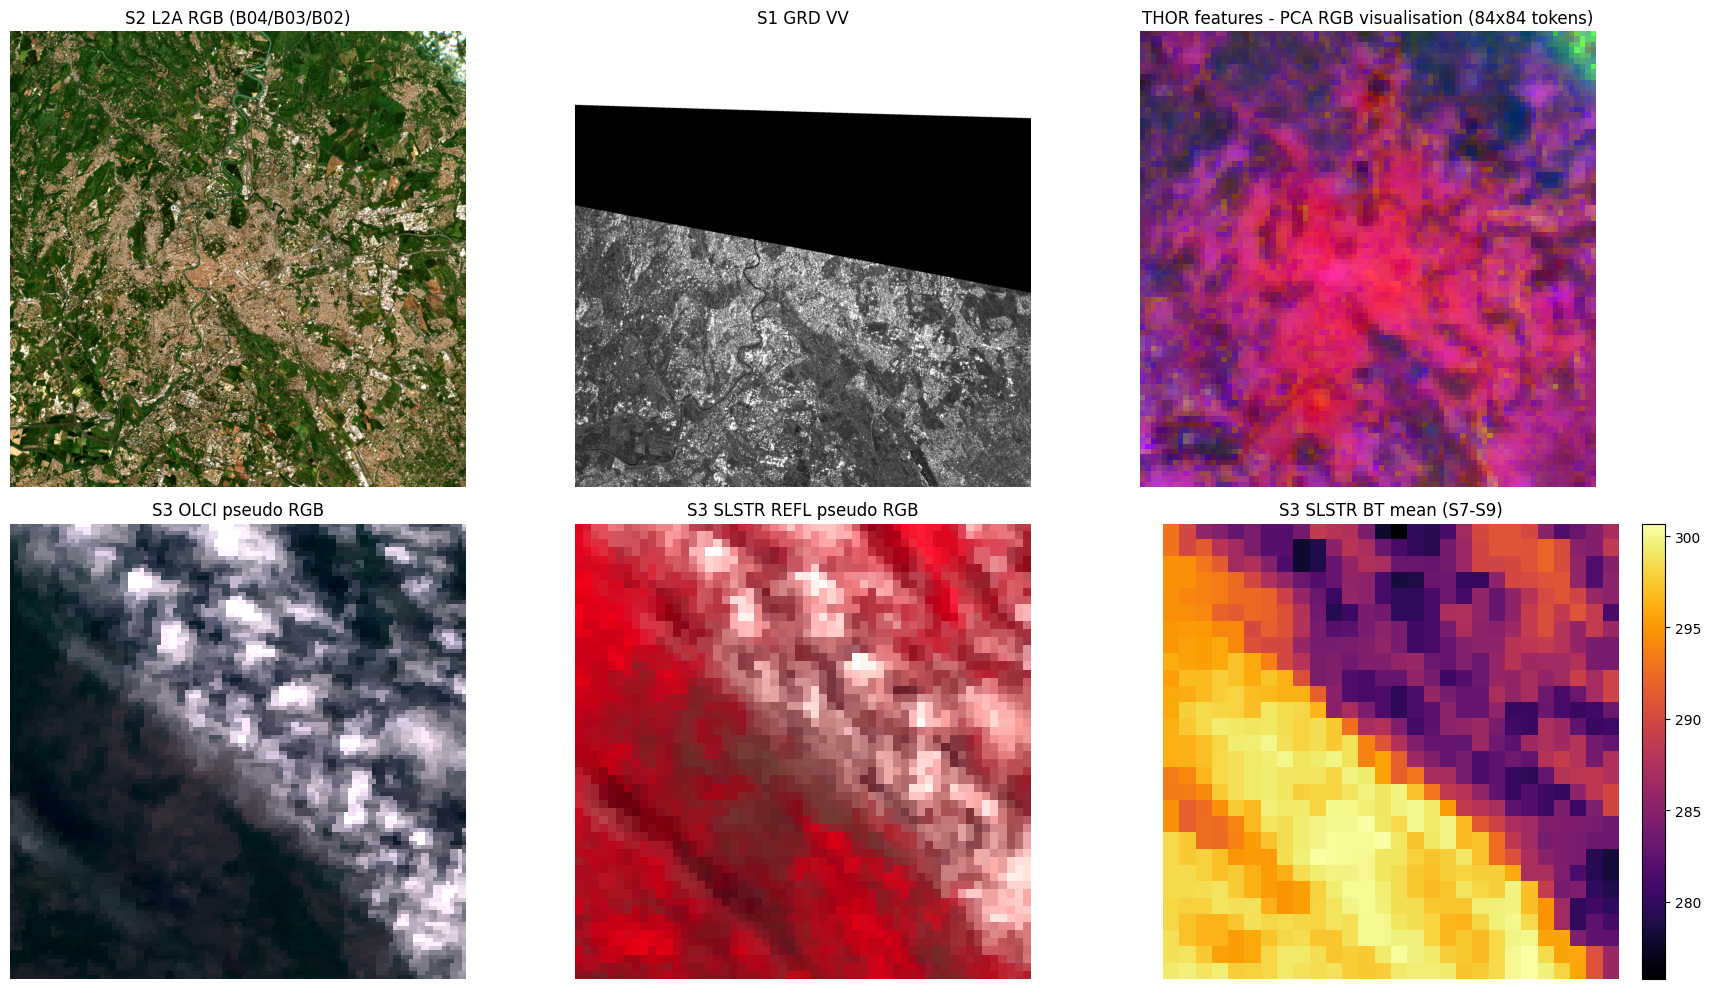

In [9]:
from terratorch.datasets.utils import to_pca_rgb


def pca_viz(feature_chw, step=1):
    pca_rgb, _H, _W = to_pca_rgb(feature_chw.cpu().numpy(), step=step)
    return pca_rgb


def robust_stretch(x, p_low=2, p_high=98):
    x = x.astype(np.float32)
    if np.all(np.isnan(x)):
        return np.zeros_like(x, dtype=np.float32)
    lo, hi = np.nanpercentile(x, [p_low, p_high])
    return np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)


last = features[-1]  # (1, D, H, W)
H, W = last.shape[2:]
pca_img = pca_viz(last[0], step=10)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()


# RGB preview of S2
s2 = arrays[ThorModalities.S2L2A]
s2_rgb = np.stack([s2[3], s2[2], s2[1]], axis=-1)
axes[0].imshow(robust_stretch(s2_rgb))
axes[0].set_title("S2 L2A RGB (B04/B03/B02)")
axes[0].axis("off")

# S1 VV (channel 0)
s1 = arrays[ThorModalities.S1GRD_VV_VH]
axes[1].imshow(robust_stretch(s1[0]), cmap="gray")
axes[1].set_title("S1 GRD VV")
axes[1].axis("off")


# PCA visualisation
axes[2].imshow(pca_img)
axes[2].set_title(f"THOR features - PCA RGB visualisation ({H}x{W} tokens)")
axes[2].axis("off")

# --- S3 OLCI pseudo RGB ---
s3_olci = arrays[ThorModalities.S3OLCI]
olci_idx = [7, 5, 3] if s3_olci.shape[0] >= 8 else [2, 1, 0]
s3_olci_rgb = np.stack(
    [s3_olci[olci_idx[0]], s3_olci[olci_idx[1]], s3_olci[olci_idx[2]]], axis=-1
)
axes[3].imshow(robust_stretch(s3_olci_rgb))
axes[3].set_title("S3 OLCI pseudo RGB")
axes[3].axis("off")

# --- S3 SLSTR reflectance pseudo RGB (S3,S2,S1) ---
s3_refl = arrays[ThorModalities.S3SLSTR_REFL]
refl_idx = [2, 1, 0] if s3_refl.shape[0] >= 3 else [0, 0, 0]
s3_refl_rgb = np.stack(
    [s3_refl[refl_idx[0]], s3_refl[refl_idx[1]], s3_refl[refl_idx[2]]], axis=-1
)
axes[4].imshow(robust_stretch(s3_refl_rgb))
axes[4].set_title("S3 SLSTR REFL pseudo RGB")
axes[4].axis("off")

# --- S3 SLSTR BT (mean of S7-S9) ---
s3_bt = arrays[ThorModalities.S3SLSTR_BT]
bt_mean = np.nanmean(s3_bt, axis=0)
im = axes[5].imshow(bt_mean, cmap="inferno")
axes[5].set_title("S3 SLSTR BT mean (S7-S9)")
axes[5].axis("off")
plt.colorbar(im, ax=axes[5], fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

## Per-group forward pass (`merge_method="group"`)

Re-run with `merge_method="group"` (or `merge_method=None` in the backbone) to
retain separate token sequences per group or one long sequence, which is useful for downstream heads
that want to treat modalities independently.

With `merge_method="group"` each group keeps its own token grid at native
spatial resolution. The output per encoder block is a
`dict[str, Tensor(B, D, H, W)]` instead of a single tensor.


In [10]:
backbone_group = BACKBONE_REGISTRY.build(
    MODEL_NAME,
    pretrained=True,
    # model_bands=ALL_BANDS,
    modalities={
        "S1GRD": S1_BANDS,
        "S2L2A": S2_BANDS,
        "S3OLCI": S3_OLCI_BANDS,
        "S3SLSTR_REFL": S3_SLSTR_BANDS[:6],  # S1–S6
        "S3SLSTR_BT": S3_SLSTR_BANDS[6:],  # S7–S9
    },
    ground_cover=GROUND_COVER,
    patch_sizes={
        "S1GRD": [32],
        "S2L2A": [32],
        "S3OLCI": [16],
        "S3SLSTR_REFL": [8],
        "S3SLSTR_BT": [4],
    },
    select_patch_strategy="max",
    merge_method="group",
)
backbone_group = backbone_group.to(DEVICE).eval()

with torch.no_grad():
    group_features = backbone_group(inputs)

# group_features is a list of dictionaries with entries as {group_name: (1, D, H, W) tensors} – one per encoder block
last_group = group_features[-1]
for group_name, group_tensor in last_group.items():
    print(
        f"Group '{group_name}' (last layer): {tuple(group_tensor.shape)}  "
        f"→ [{group_tensor.shape[2]}, {group_tensor.shape[3]}] tokens x {group_tensor.shape[1]}-dim embedding"
    )

2026-04-14 15:01:25,785 - INFO - Deriving model bands from modalities: {'S1GRD': [<SARThorBands.IW_VV: 'IW_VV'>, <SARThorBands.IW_VH: 'IW_VH'>], 'S2L2A': [<S2L2ABands.COASTAL_AEROSOL: 'COASTAL_AEROSOL'>, <S2L2ABands.BLUE: 'BLUE'>, <S2L2ABands.GREEN: 'GREEN'>, <S2L2ABands.RED: 'RED'>, <S2L2ABands.RED_EDGE_1: 'RED_EDGE_1'>, <S2L2ABands.RED_EDGE_2: 'RED_EDGE_2'>, <S2L2ABands.RED_EDGE_3: 'RED_EDGE_3'>, <S2L2ABands.NIR_BROAD: 'NIR_BROAD'>, <S2L2ABands.NIR_NARROW: 'NIR_NARROW'>, <S2L2ABands.WATER_VAPOR: 'WATER_VAPOR'>, <S2L2ABands.SWIR_1: 'SWIR_1'>, <S2L2ABands.SWIR_2: 'SWIR_2'>], 'S3OLCI': [<S3OLCIBands.OA01_REFLECTANCE: 'OA01_REFLECTANCE'>, <S3OLCIBands.OA02_REFLECTANCE: 'OA02_REFLECTANCE'>, <S3OLCIBands.OA03_REFLECTANCE: 'OA03_REFLECTANCE'>, <S3OLCIBands.OA04_REFLECTANCE: 'OA04_REFLECTANCE'>, <S3OLCIBands.OA05_REFLECTANCE: 'OA05_REFLECTANCE'>, <S3OLCIBands.OA06_REFLECTANCE: 'OA06_REFLECTANCE'>, <S3OLCIBands.OA07_REFLECTANCE: 'OA07_REFLECTANCE'>, <S3OLCIBands.OA08_REFLECTANCE: 'OA08_REFLEC

Group 'S2:Red' (last layer): (1, 192, 84, 84)  → [84, 84] tokens x 192-dim embedding
Group 'S2:RE1' (last layer): (1, 192, 42, 42)  → [42, 42] tokens x 192-dim embedding
Group 'S2:CoastAerosal' (last layer): (1, 192, 14, 14)  → [14, 14] tokens x 192-dim embedding
Group 'S1:IW-VH' (last layer): (1, 192, 84, 84)  → [84, 84] tokens x 192-dim embedding
Group 'S3:Oa01_reflectance' (last layer): (1, 192, 7, 7)  → [7, 7] tokens x 192-dim embedding
Group 'S3:Oa08_reflectance' (last layer): (1, 192, 7, 7)  → [7, 7] tokens x 192-dim embedding
Group 'S3:Oa15_reflectance' (last layer): (1, 192, 7, 7)  → [7, 7] tokens x 192-dim embedding
Group 'S3:S1_reflectance_an' (last layer): (1, 192, 7, 7)  → [7, 7] tokens x 192-dim embedding
Group 'S3:S7_BT_in' (last layer): (1, 192, 7, 7)  → [7, 7] tokens x 192-dim embedding


## Per-group PCA visualisation

Each modality group produces its own `(D, H, W)` feature grid at native token
resolution. The PCA projection is computed independently per group.

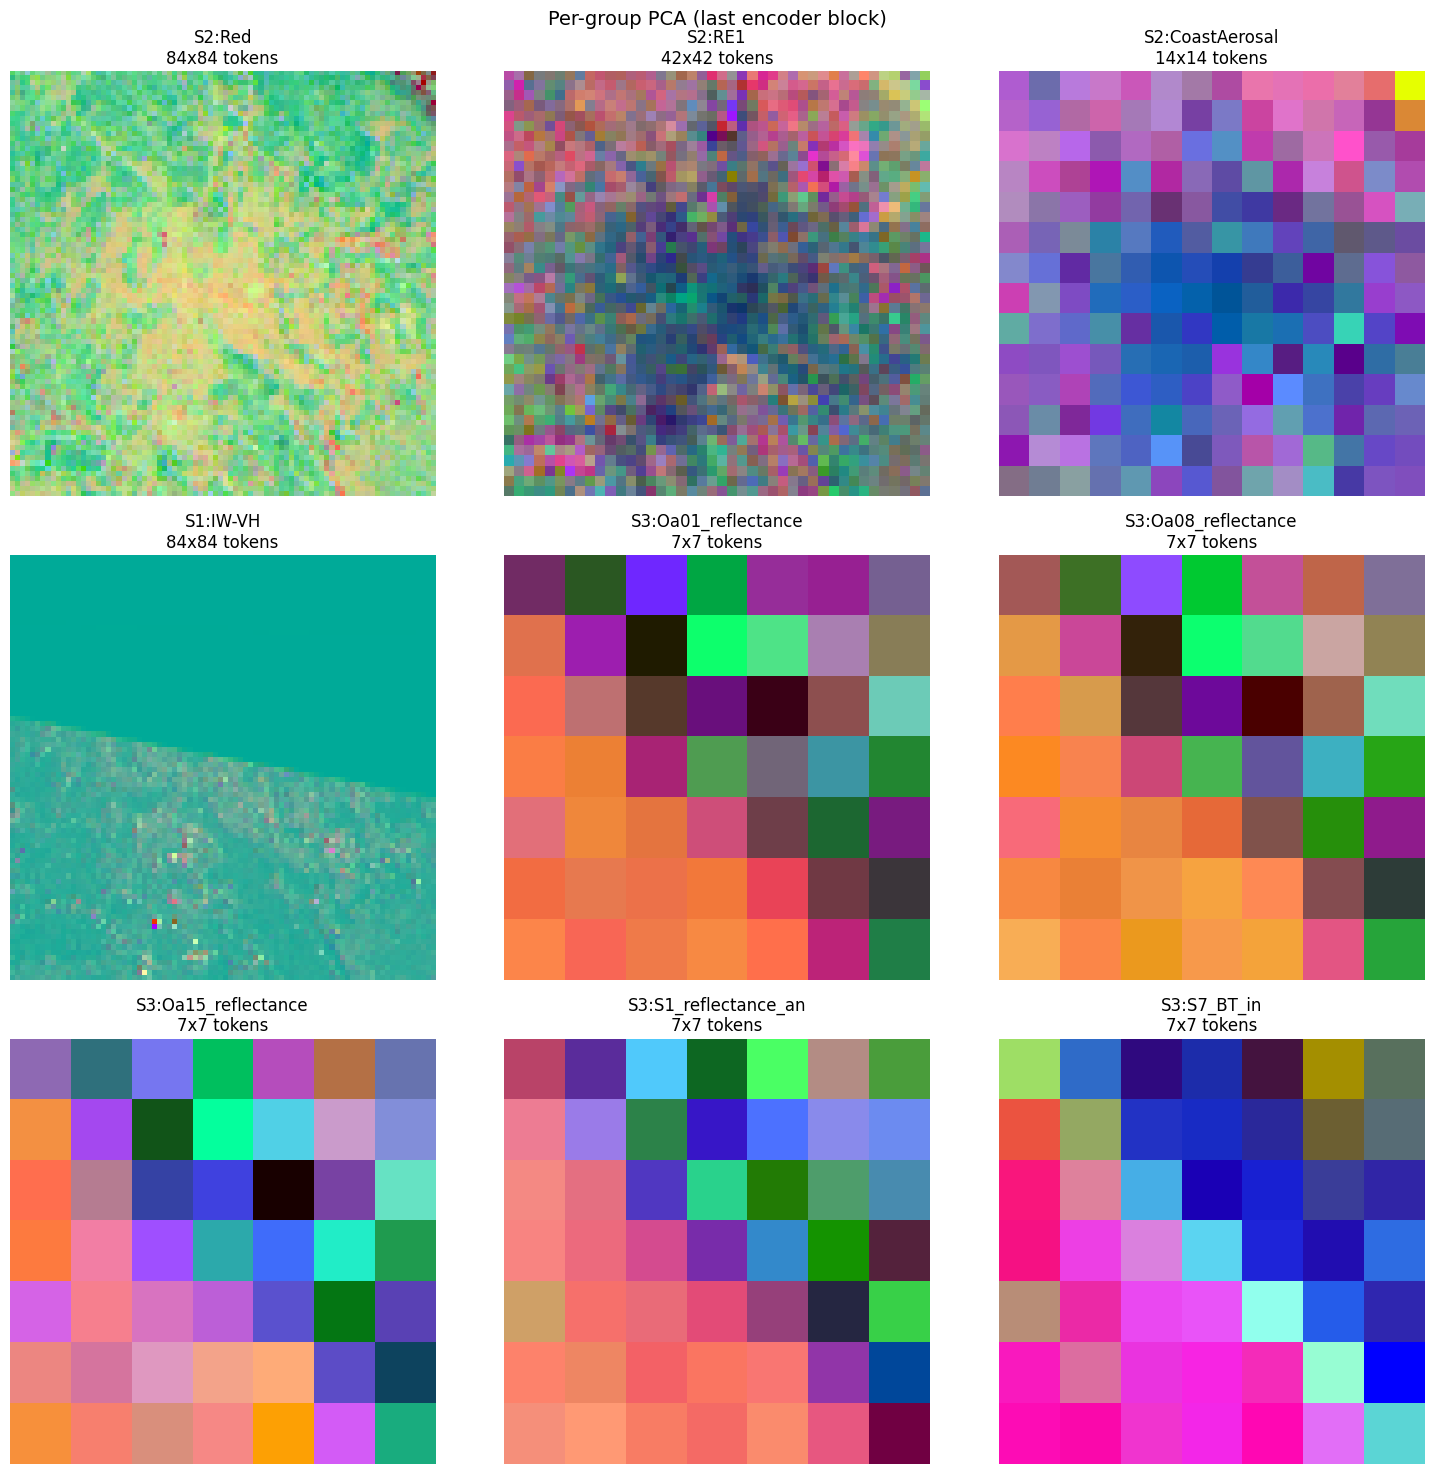

In [11]:
n_groups = len(last_group)
fig, axes = plt.subplots(3, 3, figsize=(5 * 3, 5 * 3))
if n_groups == 1:
    axes = [axes]

for ax, (name, tensor) in zip(axes.flatten(), last_group.items()):
    feat = tensor[0]  # (D, H, W)
    H_g, W_g = feat.shape[1:]
    img = pca_viz(feat, step=max(1, min(H_g, W_g) // 8))
    ax.imshow(img)
    ax.set_title(f"{name}\n{H_g}x{W_g} tokens")
    ax.axis("off")

fig.suptitle("Per-group PCA (last encoder block)", fontsize=14)
plt.tight_layout()
plt.show()